Saved: FigS1E/FigS1E.svg


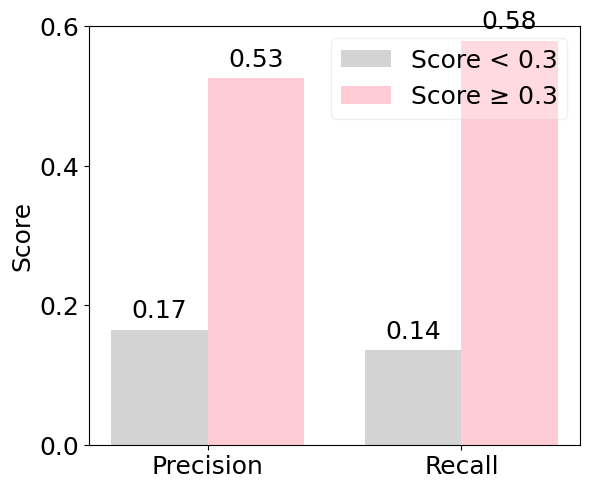

In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams.update({'xtick.labelsize': 18, 'ytick.labelsize': 18})
# -------------------------
# Style (robust across envs)
# -------------------------
try:
    plt.style.use("seaborn-v0_8-pastel")
except OSError:
    try:
        plt.style.use("seaborn-pastel")
    except OSError:
        import seaborn as sns
        sns.set_theme(style="whitegrid", palette="pastel")

# -------------------------
# Config
# -------------------------
WKDIR = "FigS1E/"
IN_FILE = f"{WKDIR}interface_all_interspecies_AFM_ESM_all_score_pdockq_benchmark_with_info.txt"
OUT_SVG = f"{WKDIR}FigS1E.svg"

PLDDT_THR = (50.0, 100.0)   # AFM interface pLDDT threshold
DSASA_MIN = 1.0
RSASA_MIN = 15.0
EPS = 1e-5
SCORE_CUT = 0.3             # split at 0.3

# -------------------------
# Helpers
# -------------------------
def convert_ires_string_to_list(ires_string: str):
    """'[10,12-15,20]' -> [10,12,13,14,15,20]; empty -> []"""
    s = ires_string.replace("[", "").replace("]", "")
    if s.strip() == "":
        return []
    segs = s.split(",")
    blocks = [
        list(range(int(t.split("-")[0]), int(t.split("-")[1]) + 1)) if "-" in t else [int(t)]
        for t in segs
    ]
    return [x for block in blocks for x in block]

def calc_res_set(IresA_all, IresB_all, pIresA_all, pIresB_all):
    """Micro-averaged precision/recall over all residues (both chains)."""
    i1 = len(set(pIresA_all) & set(IresA_all))
    i2 = len(set(pIresB_all) & set(IresB_all))
    pre = round((i1 + i2) / (len(pIresA_all) + len(pIresB_all) + EPS), 3)
    rec = round((i1 + i2) / (len(IresA_all) + len(IresB_all) + EPS), 3)
    return pre, rec

# -------------------------
# Load table
# -------------------------
df = pd.read_csv(IN_FILE, sep="\t")
df = df[df.score>=0]

# -------------------------
# Accumulators per score bin
# -------------------------
IresA_low, IresB_low, pA_low, pB_low = [], [], [], []
IresA_high, IresB_high, pA_high, pB_high = [], [], [], []

plddt_min, plddt_max = PLDDT_THR

# -------------------------
# Walk rows; compute AFM interfaces & truth; bin by score
# -------------------------
for (
    UniProtA, UniProtB,
    UniProtIresA, UniProtIresB,
    ProtA_rSASA, ProtB_rSASA,
    ProtA_dSASA, ProtB_dSASA,
    ProtA_res_range, ProtB_res_range,
    ProtA_ires_plddt, ProtB_ires_plddt,
    score
) in df[
    [
        "UniProtA","UniProtB",
        "UniProtIresA","UniProtIresB",
        "ProtA_rSASA","ProtB_rSASA",
        "ProtA_dSASA","ProtB_dSASA",
        "ProtA_res_range","ProtB_res_range",
        "ProtA_ires_plddt","ProtB_ires_plddt",
        "score"
    ]
].itertuples(index=False):

    # Ground-truth interface residues (Uniprot indexing)
    gtA = convert_ires_string_to_list(UniProtIresA)
    gtB = convert_ires_string_to_list(UniProtIresB)

    # AFM per-residue arrays
    resA = np.array([int(x) for x in ProtA_res_range.replace("\n","")[1:-1].split(",")]) if ProtA_res_range != "[]" else np.array([], dtype=int)
    resB = np.array([int(x) for x in ProtB_res_range.replace("\n","")[1:-1].split(",")]) if ProtB_res_range != "[]" else np.array([], dtype=int)

    dA   = np.array([float(x) for x in ProtA_dSASA.split(",")]) if ProtA_dSASA else np.array([])
    dB   = np.array([float(x) for x in ProtB_dSASA.split(",")]) if ProtB_dSASA else np.array([])
    rA   = np.array([float(x) for x in ProtA_rSASA.split(",")]) if ProtA_rSASA else np.array([])
    rB   = np.array([float(x) for x in ProtB_rSASA.split(",")]) if ProtB_rSASA else np.array([])
    pldA = np.array([float(x) for x in ProtA_ires_plddt.replace("\n","").split(",")]) if ProtA_ires_plddt else np.array([])
    pldB = np.array([float(x) for x in ProtB_ires_plddt.replace("\n","").split(",")]) if ProtB_ires_plddt else np.array([])

    if resA.size == 0 or resB.size == 0 or dA.size == 0 or dB.size == 0 or rA.size == 0 or rB.size == 0 or pldA.size == 0 or pldB.size == 0:
        continue  # skip malformed rows

    # AFM predicted interfaces by structural thresholds
    selA = (dA >= DSASA_MIN) & (rA >= RSASA_MIN) & (pldA > plddt_min) & (pldA <= plddt_max)
    selB = (dB >= DSASA_MIN) & (rB >= RSASA_MIN) & (pldB > plddt_min) & (pldB <= plddt_max)
    predA = resA[selA]
    predB = resB[selB]
    if predA.size == 0 or predB.size == 0:
        continue  # follow earlier logic: require interface on both chains

    # String-encode to match earlier set-intersections (pair+chain+index)
    IresA_str = [f"{UniProtA}_{UniProtB}_{UniProtA}_{i}" for i in gtA]
    IresB_str = [f"{UniProtA}_{UniProtB}_{UniProtB}_{i}" for i in gtB]
    pIresA_str = [f"{UniProtA}_{UniProtB}_{UniProtA}_{i}" for i in predA]
    pIresB_str = [f"{UniProtA}_{UniProtB}_{UniProtB}_{i}" for i in predB]

    # Bin by score
    if score < SCORE_CUT:
        IresA_low += IresA_str;  IresB_low += IresB_str
        pA_low    += pIresA_str; pB_low    += pIresB_str
    else:
        IresA_high += IresA_str;  IresB_high += IresB_str
        pA_high    += pIresA_str; pB_high    += pIresB_str

# -------------------------
# Compute micro-averaged precision/recall per bin
# -------------------------
pre_low,  rec_low  = (0.0, 0.0) if (len(pA_low)  == 0 or len(IresA_low)  == 0) else calc_res_set(IresA_low,  IresB_low,  pA_low,  pB_low)
pre_high, rec_high = (0.0, 0.0) if (len(pA_high) == 0 or len(IresA_high) == 0) else calc_res_set(IresA_high, IresB_high, pA_high, pB_high)

# -------------------------
# One figure: grouped bars (Precision & Recall) by score bin
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5))
labels = ["Precision", "Recall"]
low_vals  = [pre_low,  rec_low]
high_vals = [pre_high, rec_high]

x = np.arange(len(labels))
w = 0.38

b1 = ax.bar(x - w/2, low_vals,  width=w, label=f"Score < {SCORE_CUT}",  color="lightgray")
b2 = ax.bar(x + w/2, high_vals, width=w, label=f"Score ≥ {SCORE_CUT}", color="pink", alpha=0.8)

# annotate values on bars
for bars in (b1, b2):
    for r in bars:
        v = r.get_height()
        ax.text(r.get_x() + r.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=18)

ax.set_xticks(x, labels, rotation=0)
ax.set_ylabel("Score", fontsize=18)
ax.set_ylim(0, 0.6)
ax.set_yticks([0, 0.2, 0.4, 0.6])
ax.legend(framealpha=0.3, fontsize=18)
ax.yaxis.grid(False)
fig.tight_layout()
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight")
print(f"Saved: {OUT_SVG}")
